In [1]:
# Cancer-specific POG570 treatment-by-gene analysis
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter
import seaborn as sns
from lifelines import CoxPHFitter

In [2]:
USE_CANCER_SPECIFIC_DRIVER_GENES = True
CANCER_TYPES = ["BRCA"]  # set to None for all cancer types, or a list such as ["BRCA", "COLO"]
INCLUDE_CANCER_TYPE_COVARIATE = CANCER_TYPES is None

GENOMIC_FEATURE_GENE = None  # set to a gene symbol, e.g. "TP53", for a gene-specific feature
GENOMIC_FEATURE_SCORER = "PATIENT_SINGLE_TRACK_SCORER"
GENOMIC_FEATURE_AGGREGATION = "L2_DIFF"
# ATAC, DNASE, CHIP_HISTONE, CHIP_TF, RNA_SEQ, CAGE, SPLICE_SITE_USAGE
GENOMIC_FEATURE_OUTPUT_TYPES = None  # set to a list, e.g. ["ATAC"], to restrict modalities
TOP_N_GENES_BY_DISRUPTION = None # genes with highest median disruption and IQR (variance) across patients
WINSORIZE_SCORE_QUANTILES = (0.05, 0.95)

In [3]:
CANCER_SPECIFIC_PATIENT_DISRUPTION_DATA = "../data/alphagenome_scores/pog570_patient_tissue_tracks_local_cancer_specific/patients"
PANCANCER_PATIENT_DISRUPTION_DATA = "../data/alphagenome_scores/pog570_patient_tissue_tracks_local/patients"
DRIVER_GENE_MODE = "cancer_specific" if USE_CANCER_SPECIFIC_DRIVER_GENES else "pancancer"
PATIENT_DISRUPTION_DATA = CANCER_SPECIFIC_PATIENT_DISRUPTION_DATA if USE_CANCER_SPECIFIC_DRIVER_GENES else PANCANCER_PATIENT_DISRUPTION_DATA
PATIENT_COHORT_MAP = "../metadata/pog570_patient_analysis_cohort_mapping.tsv"

TREATMENT_DATA = "../data/POG570/treatment.csv"
SURVIVAL_DATA = "../data/POG570/survival.csv"
CLINICAL_DATA = "../data/POG570/clinical_demographic.csv"
SMALL_MUTATION_DATA = "../data/POG570/POG570_small_mutations.txt"

OUTPUT_DIR = Path(f"../results/pog570_treatmentxgene_{DRIVER_GENE_MODE}")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Driver gene score mode:", DRIVER_GENE_MODE)
print("Patient disruption data:", PATIENT_DISRUPTION_DATA)
print("Output directory:", OUTPUT_DIR)

Driver gene score mode: cancer_specific
Patient disruption data: ../data/alphagenome_scores/pog570_patient_tissue_tracks_local_cancer_specific/patients
Output directory: ../results/pog570_treatmentxgene_cancer_specific


In [4]:
# list of patients
patient_cohort_map = pd.read_csv(PATIENT_COHORT_MAP, sep="	")
all_patients_list = patient_cohort_map["patient_id"].unique()
print("All Patients:", len(all_patients_list), all_patients_list[:5])
if CANCER_TYPES is None:
    patient_cancer_types = patient_cohort_map.copy()
else:
    patient_cancer_types = patient_cohort_map[patient_cohort_map["analysis_cohort"].isin(CANCER_TYPES)].copy()
selected_patients_list = patient_cancer_types["patient_id"].unique()
print("Selected Patients:", len(selected_patients_list), selected_patients_list[:5])
print("Selected cancer types:", sorted(patient_cancer_types["analysis_cohort"].dropna().unique()))


All Patients: 570 [11004 11307 11698 12255 13009]
Selected Patients: 144 [11307 13268 14231 15122 15227]
Selected cancer types: ['BRCA']


In [5]:
# patient clinical data
clinical_df = pd.read_csv(CLINICAL_DATA)
print(clinical_df.shape)
clinical_df.dropna(subset=["PATIENT_ID"], inplace=True)
print(clinical_df.shape)
clinical_df["PATIENT_ID"] = clinical_df["PATIENT_ID"].apply(lambda x: str(int(x)))
clinical_df = clinical_df[["PATIENT_ID", "AGE", "GENDER", "TUMOUR_TYPE", "BIOPSY_SITE", "BIOPSY_COHORT", "ANALYSIS_COHORT", "METASTATIC_OR_RECURRENCE", "TUMOUR_CONTENT"]]
print(clinical_df.shape)
clinical_df.head()

(999, 14)
(570, 14)
(570, 9)


,PATIENT_ID,AGE,GENDER,TUMOUR_TYPE,BIOPSY_SITE,BIOPSY_COHORT,ANALYSIS_COHORT,METASTATIC_OR_RECURRENCE,TUMOUR_CONTENT
0,11004,30,F,Colorectal Adenocarcinoma,Liver,Liver,COLO,Metastatic,73.0
1,11307,48,F,Breast Invasive Ductal Carcinoma,Liver,Liver,BRCA,Metastatic,59.0
2,11698,64,M,Basal Cell Carcinoma,Skin,Skin,BCC,Metastatic,43.0
3,12255,34,M,Atypical Teratoid/Rhabdoid Tumor,Sinus,Head & Neck,SARC,Local,60.0
4,13009,unknown,F,Atypical CLL,Bone Marrow,Bone,LYMP,Local,100.0


In [6]:
# add survival data
survival_df = pd.read_csv(SURVIVAL_DATA)
print(survival_df.shape)
survival_df.rename(columns={
    "Patient_ID": "PATIENT_ID",
    "Overall_survival_days": "OS.time",
    "Alive_0_Death_1": "OS.event"
}, inplace=True)
survival_df["PATIENT_ID"] = survival_df["PATIENT_ID"].apply(lambda x: str(int(x)))
clinical_df = pd.merge(clinical_df, survival_df, how="left", on="PATIENT_ID")
print(clinical_df.shape)
clinical_df.head()

(570, 3)
(570, 11)


,PATIENT_ID,AGE,GENDER,TUMOUR_TYPE,BIOPSY_SITE,BIOPSY_COHORT,ANALYSIS_COHORT,METASTATIC_OR_RECURRENCE,TUMOUR_CONTENT,OS.time,OS.event
0,11004,30,F,Colorectal Adenocarcinoma,Liver,Liver,COLO,Metastatic,73.0,247,1
1,11307,48,F,Breast Invasive Ductal Carcinoma,Liver,Liver,BRCA,Metastatic,59.0,836,1
2,11698,64,M,Basal Cell Carcinoma,Skin,Skin,BCC,Metastatic,43.0,2554,1
3,12255,34,M,Atypical Teratoid/Rhabdoid Tumor,Sinus,Head & Neck,SARC,Local,60.0,294,1
4,13009,unknown,F,Atypical CLL,Bone Marrow,Bone,LYMP,Local,100.0,2196,0


In [7]:
# add tumor mutation burden as log1p small mutation count per patient
small_mutation_df = pd.read_csv(SMALL_MUTATION_DATA, sep="	", usecols=["patient_id"])
tmb_df = (
    small_mutation_df
    .dropna(subset=["patient_id"])
    .assign(PATIENT_ID=lambda df: df["patient_id"].astype(int).astype(str))
    .groupby("PATIENT_ID", as_index=False)
    .size()
    .rename(columns={"size": "small_mutation_count"})
)
tmb_df["TMB"] = np.log1p(tmb_df["small_mutation_count"])
clinical_df = clinical_df.merge(tmb_df[["PATIENT_ID", "TMB"]], on="PATIENT_ID", how="left")
clinical_df["TMB"] = clinical_df["TMB"].fillna(0.0)
print(clinical_df.shape)
clinical_df.head()


(570, 12)


,PATIENT_ID,AGE,GENDER,TUMOUR_TYPE,BIOPSY_SITE,BIOPSY_COHORT,ANALYSIS_COHORT,METASTATIC_OR_RECURRENCE,TUMOUR_CONTENT,OS.time,OS.event,TMB
0,11004,30,F,Colorectal Adenocarcinoma,Liver,Liver,COLO,Metastatic,73.0,247,1,9.541585
1,11307,48,F,Breast Invasive Ductal Carcinoma,Liver,Liver,BRCA,Metastatic,59.0,836,1,8.417152
2,11698,64,M,Basal Cell Carcinoma,Skin,Skin,BCC,Metastatic,43.0,2554,1,12.939968
3,12255,34,M,Atypical Teratoid/Rhabdoid Tumor,Sinus,Head & Neck,SARC,Local,60.0,294,1,8.243283
4,13009,unknown,F,Atypical CLL,Bone Marrow,Bone,LYMP,Local,100.0,2196,0,7.875499


In [8]:
# days are relative to first event (start of first recorded treatment)
treatment_df = pd.read_csv(TREATMENT_DATA)
print(treatment_df.shape)
treatment_df = treatment_df[treatment_df["Patient_ID"].isin(selected_patients_list)]
print(treatment_df.shape)
treatment_df.head()

(1987, 9)
(867, 9)


,Patient_ID,Drug_name,Treatment_course_number,Class_1,Class_2,Pathway,Therapy_start_date,Therapy_end_or_biopsy_date,On_treatment_at_biopsy
3,11307,DOCETAXEL,1,taxanes,mitotic inhibitor,mitotic inhibitor,0,105,0
4,11307,FLUOROURACIL,1,DNA synthesis inhibitor,antimetabolite,DNA synthesis,0,105,0
5,11307,CYCLOPHOSPHAMIDE,1,DNA alkylating,DNA damage inducer,DNA damage,0,105,0
6,11307,EPIRUBICIN,1,anthracyclines,DNA synthesis inhibitor,DNA synthesis,0,105,0
7,11307,TAMOXIFEN,2,estrogen receptor antagonist,hormone therapy,Hormone,160,830,0


In [9]:
treatment_df["Class_2"].value_counts()

Class_2
hormone therapy            274
DNA damage inducer         145
antimetabolite             128
mitotic inhibitor          125
DNA synthesis inhibitor    101
kinase inhibitor            88
misc                         3
immunotherapy                3
Name: count, dtype: int64

In [10]:
patient_treatment_combinations = treatment_df.groupby("Patient_ID")["Class_2"].apply(lambda x: list(x.unique())).reset_index()
patient_treatment_combinations["num_unique_treatments"] = patient_treatment_combinations["Class_2"].apply(lambda x: len(x))
print(patient_treatment_combinations.shape)
patient_treatment_combinations.head()

(142, 3)


,Patient_ID,Class_2,num_unique_treatments
0,11307,"[mitotic inhibitor, antimetabolite, DNA damage...",6
1,13268,"[antimetabolite, DNA damage inducer, mitotic i...",5
2,14231,"[DNA synthesis inhibitor, mitotic inhibitor, D...",4
3,15122,"[mitotic inhibitor, DNA damage inducer, DNA sy...",4
4,15227,"[antimetabolite, DNA synthesis inhibitor, DNA ...",4


In [11]:
# Get one combined AlphaGenome score per patient-gene pair, then summarize to a patient-level feature.
def load_completed_genes(patient_id):
    completed_path = Path(PATIENT_DISRUPTION_DATA) / f"{patient_id}.completed_patient_genes.tsv"
    if not completed_path.exists():
        return set()
    completed_df = pd.read_csv(completed_path, sep="	", dtype=str)
    if "gene" not in completed_df.columns:
        return set()
    return set(completed_df["gene"].dropna().astype(str))


def load_patient_gene_scores(patient_ids):
    rows = []
    for patient_id in patient_ids:
        patient_id = str(patient_id)
        patient_path = Path(PATIENT_DISRUPTION_DATA) / f"{patient_id}.csv"
        completed_genes = load_completed_genes(patient_id)
        if not patient_path.exists() and not completed_genes:
            continue

        if patient_path.exists():
            df = pd.read_csv(patient_path)
            df = df[
                df["scorer"].eq(GENOMIC_FEATURE_SCORER)
                & df["aggregation_type"].eq(GENOMIC_FEATURE_AGGREGATION)
                & df["score_region"].eq("gene")
            ].copy()
            if GENOMIC_FEATURE_GENE is not None:
                df = df[df["gene"].eq(GENOMIC_FEATURE_GENE)]
            if GENOMIC_FEATURE_OUTPUT_TYPES is not None:
                df = df[df["output_type"].isin(GENOMIC_FEATURE_OUTPUT_TYPES)]
            df["score"] = pd.to_numeric(df["score"], errors="coerce")
            df = df.dropna(subset=["gene", "score"])
            observed_gene_scores = (
                df.groupby("gene")
                .agg(
                    gene_combined_score=("score", lambda x: x.abs().mean()),
                    n_observed_score_rows=("score", "size"),
                )
                .reset_index()
            )
        else:
            observed_gene_scores = pd.DataFrame(columns=["gene", "gene_combined_score", "n_observed_score_rows"])

        expected_genes = set(observed_gene_scores["gene"]) | completed_genes
        if GENOMIC_FEATURE_GENE is not None:
            expected_genes = {GENOMIC_FEATURE_GENE} if GENOMIC_FEATURE_GENE in expected_genes else set()

        observed_gene_scores = observed_gene_scores.set_index("gene")
        for gene in sorted(expected_genes):
            if gene in observed_gene_scores.index:
                rows.append({
                    "PATIENT_ID": patient_id,
                    "gene": gene,
                    "gene_combined_score": observed_gene_scores.loc[gene, "gene_combined_score"],
                    "n_observed_score_rows": int(observed_gene_scores.loc[gene, "n_observed_score_rows"]),
                    "zero_filled_completed_gene": False,
                })
            elif gene in completed_genes:
                rows.append({
                    "PATIENT_ID": patient_id,
                    "gene": gene,
                    "gene_combined_score": 0.0,
                    "n_observed_score_rows": 0,
                    "zero_filled_completed_gene": True,
                })
    return pd.DataFrame(rows)


def winsorized_variance(values):
    values = pd.to_numeric(values, errors="coerce").dropna()
    if values.empty:
        return 0.0
    lower_q, upper_q = WINSORIZE_SCORE_QUANTILES
    clipped = values.clip(values.quantile(lower_q), values.quantile(upper_q))
    return clipped.var()


patient_gene_score_df = load_patient_gene_scores(selected_patients_list)
gene_disruption_summary_df = (
    patient_gene_score_df
    .groupby("gene", as_index=False)
    .agg(
        winsorized_variance_gene_combined_score=("gene_combined_score", winsorized_variance),
        variance_gene_combined_score=("gene_combined_score", "var"),
        iqr_gene_combined_score=("gene_combined_score", lambda x: x.quantile(0.75) - x.quantile(0.25)),
        mean_gene_combined_score=("gene_combined_score", "mean"),
        median_gene_combined_score=("gene_combined_score", "median"),
        n_nonzero_patients=("gene_combined_score", lambda x: int((x != 0).sum())),
        n_patients=("PATIENT_ID", "nunique"),
    )
    .fillna({"winsorized_variance_gene_combined_score": 0.0, "variance_gene_combined_score": 0.0, "iqr_gene_combined_score": 0.0})
    .sort_values(["median_gene_combined_score", "winsorized_variance_gene_combined_score", "iqr_gene_combined_score", "variance_gene_combined_score"], ascending=False)
    .reset_index(drop=True)
)
gene_disruption_summary_df.head()


,gene,winsorized_variance_gene_combined_score,variance_gene_combined_score,iqr_gene_combined_score,mean_gene_combined_score,median_gene_combined_score,n_nonzero_patients,n_patients
0,RUNX1,58538.041745,68427.920685,3.117509,119.415648,11.126922,114,144
1,PIK3R1,69276.660261,70214.190442,2.655122,109.235308,10.269231,115,144
2,RB1,76428.159686,103085.801406,11.652429,104.201112,9.849508,100,144
3,ARID1A,36155.949024,48009.965404,11.055797,71.825911,9.490937,107,144
4,NCOR1,67289.469927,77186.528212,10.410130,85.943312,8.906480,106,144


In [12]:
all_gene_score_cols = sorted(patient_gene_score_df["gene"].dropna().unique())
if TOP_N_GENES_BY_DISRUPTION is None:
    ALPHAGENOME_GENE_SCORE_COLS = all_gene_score_cols
else:
    ALPHAGENOME_GENE_SCORE_COLS = gene_disruption_summary_df.head(TOP_N_GENES_BY_DISRUPTION)["gene"].tolist()

patient_gene_score_df = patient_gene_score_df[
    patient_gene_score_df["gene"].isin(ALPHAGENOME_GENE_SCORE_COLS)
].copy()
patient_gene_score_matrix = patient_gene_score_df.pivot(
    index="PATIENT_ID",
    columns="gene",
    values="gene_combined_score",
).reset_index()
patient_gene_score_matrix.columns.name = None
patient_gene_score_matrix = patient_gene_score_matrix[["PATIENT_ID", *ALPHAGENOME_GENE_SCORE_COLS]]

genomic_feature_df = (
    patient_gene_score_df
    .groupby("PATIENT_ID", as_index=False)
    .agg(
        genomic_feature=("gene_combined_score", "mean"),
        n_genomic_feature_genes=("gene", "size"),
        n_zero_filled_completed_genes=("zero_filled_completed_gene", "sum"),
    )
)

print("Selected genes:", len(ALPHAGENOME_GENE_SCORE_COLS), ALPHAGENOME_GENE_SCORE_COLS)
print("Patient-gene scores:", patient_gene_score_df.shape)
print("Patient-gene score matrix:", patient_gene_score_matrix.shape)
print("Patient-level genomic feature:", genomic_feature_df.shape)
gene_disruption_summary_df.head()


Selected genes: 30 ['AKT1', 'AR', 'ARID1A', 'ATM', 'ATP2B3', 'BRCA1', 'CBFB', 'CDH1', 'CTCF', 'ERBB2', 'ERBB3', 'ESR1', 'FAT3', 'FOXA1', 'GATA3', 'KMT2C', 'LRP1B', 'MAP2K4', 'MAP3K1', 'NCOR1', 'NF1', 'PIK3CA', 'PIK3R1', 'PTEN', 'RB1', 'RUNX1', 'SF3B1', 'SPEN', 'TBX3', 'TP53']
Patient-gene scores: (4320, 5)
Patient-gene score matrix: (144, 31)
Patient-level genomic feature: (144, 4)


,gene,winsorized_variance_gene_combined_score,variance_gene_combined_score,iqr_gene_combined_score,mean_gene_combined_score,median_gene_combined_score,n_nonzero_patients,n_patients
0,RUNX1,58538.041745,68427.920685,3.117509,119.415648,11.126922,114,144
1,PIK3R1,69276.660261,70214.190442,2.655122,109.235308,10.269231,115,144
2,RB1,76428.159686,103085.801406,11.652429,104.201112,9.849508,100,144
3,ARID1A,36155.949024,48009.965404,11.055797,71.825911,9.490937,107,144
4,NCOR1,67289.469927,77186.528212,10.410130,85.943312,8.906480,106,144


In [13]:
MIN_PATIENTS_PER_TREATMENT_GROUP = 10
MIN_EVENTS_PER_TREATMENT_GROUP = 3
COX_PENALIZER = 0.1

interaction_base_df = clinical_df.merge(patient_gene_score_matrix, on="PATIENT_ID", how="inner")
interaction_base_df = interaction_base_df[interaction_base_df["PATIENT_ID"].isin(selected_patients_list.astype(str))].copy()
interaction_base_df["OS.time"] = pd.to_numeric(interaction_base_df["OS.time"], errors="coerce")
interaction_base_df["OS.event"] = pd.to_numeric(interaction_base_df["OS.event"], errors="coerce")
interaction_base_df["AGE"] = pd.to_numeric(interaction_base_df["AGE"], errors="coerce")
interaction_base_df["TUMOUR_CONTENT"] = pd.to_numeric(interaction_base_df["TUMOUR_CONTENT"], errors="coerce")
interaction_base_df["TMB"] = pd.to_numeric(interaction_base_df["TMB"], errors="coerce")
interaction_base_df[ALPHAGENOME_GENE_SCORE_COLS] = interaction_base_df[ALPHAGENOME_GENE_SCORE_COLS].apply(pd.to_numeric, errors="coerce")
interaction_base_df = interaction_base_df.dropna(subset=["OS.time", "OS.event", *ALPHAGENOME_GENE_SCORE_COLS])
interaction_base_df = interaction_base_df[interaction_base_df["OS.time"] > 0].copy()
interaction_base_df["OS.event"] = interaction_base_df["OS.event"].astype(int)
print(interaction_base_df.shape, len(ALPHAGENOME_GENE_SCORE_COLS))
interaction_base_df.head()

(144, 42) 30


,PATIENT_ID,AGE,GENDER,TUMOUR_TYPE,BIOPSY_SITE,BIOPSY_COHORT,ANALYSIS_COHORT,METASTATIC_OR_RECURRENCE,TUMOUR_CONTENT,OS.time,...,NF1,PIK3CA,PIK3R1,PTEN,RB1,RUNX1,SF3B1,SPEN,TBX3,TP53
0,11307,48,F,Breast Invasive Ductal Carcinoma,Liver,Liver,BRCA,Metastatic,59.0,836,...,0.000000,0.000000,887.552399,6.940873,0.00000,10.513809,6.745387,8.382887,528.298388,7.547371
1,13268,35,F,Breast Invasive Ductal Carcinoma,Lymph Node,Lymphatic System,BRCA,Metastatic,70.0,2183,...,6.106508,4.519527,9.680643,0.000000,0.00000,11.091012,4.006239,10.610316,489.012855,4.641378
2,14231,54,F,Breast Invasive Ductal Carcinoma,Chest wall,Chest Wall,BRCA,Local,56.0,145,...,0.000000,0.000000,0.000000,7.672472,0.00000,10.629741,4.477929,0.000000,486.804726,519.042700
3,15122,48,F,Breast Invasive Lobular Carcinoma,Chest wall,Chest Wall,BRCA,Metastatic,55.0,2060,...,7.604433,4.441860,9.525932,9.727982,0.00000,11.340386,709.959444,8.701576,0.000000,5.557754
4,15227,50,F,Breast Invasive Ductal Carcinoma,Liver,Liver,BRCA,Metastatic,70.0,735,...,0.000000,5.387640,0.000000,9.498290,9.11184,0.000000,4.715493,9.260551,6.105237,3.325938


In [14]:
def format_p_value(p_value):
    if pd.isna(p_value):
        return "p=NA"
    if p_value < 0.001:
        return "p<0.001"
    if p_value < 0.01:
        return "p<0.01"
    return f"p={p_value:.2f}"


def format_log_power_xaxis(ax):
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
    ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax.xaxis.set_minor_formatter(NullFormatter())


def benjamini_hochberg(p_values):
    p_values = pd.Series(p_values, dtype=float)
    q_values = pd.Series(np.nan, index=p_values.index, dtype=float)
    valid = p_values.dropna().sort_values()
    if valid.empty:
        return q_values
    ranks = np.arange(1, len(valid) + 1)
    adjusted = valid.to_numpy() * len(valid) / ranks
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    q_values.loc[valid.index] = np.minimum(adjusted, 1.0)
    return q_values


## Treatment-exposed survival association by gene disruption

Fit one Cox model per treatment class using only patients ever exposed to that treatment class. Each retained gene disruption score is included as a separate covariate, so each gene's survival association is estimated while adjusting for the other retained genes in the same exposed-patient model.

Model form for each treatment class among ever-exposed patients only:

`OS ~ all_gene_scores + clinical_covariates`

Variable meanings:

- `gene`: AlphaGenome gene-level disruption score being summarized from the shared treatment-class model.
- `gene_score`: retained `gene_combined_score` from `patient_gene_score_matrix`, standardized before fitting.
- `gene_hr`: hazard ratio for a 1 SD increase in that gene's disruption score among patients ever exposed to the treatment class.
- `gene_p`: Wald p-value for that gene's coefficient, conditional on the other retained gene scores in the model.
- `gene_q`: Benjamini-Hochberg FDR across genes within the same treatment class.
- `gene_rank_within_class`: rank of each gene within its treatment class by `gene_p`.
- `USE_CANCER_SPECIFIC_DRIVER_GENES`: when `True`, use cancer-specific driver-gene score files; when `False`, use pancancer driver-gene score files.
- `TOP_N_GENES_BY_DISRUPTION`: optional integer filter that restricts all downstream gene-level analyses to the top N genes by winsorized variance of patient-level disruption scores in the analysis cohort. Leave as `None` to test all retained genes.
- `WINSORIZE_SCORE_QUANTILES`: lower and upper quantiles used to clip extreme disruption scores before ranking genes.
- Clinical covariates: `AGE`, `TUMOUR_CONTENT`, `TMB`, `GENDER`, and `METASTATIC_OR_RECURRENCE`. When `CANCER_TYPES = None`, `ANALYSIS_COHORT` is also included as a cancer-type covariate.


In [15]:
TREATMENT_CLASS_COL = "Class_2"
treatment_exposure_df = treatment_df.copy()
treatment_exposure_df = treatment_exposure_df.dropna(subset=["Patient_ID", TREATMENT_CLASS_COL])
treatment_exposure_df["PATIENT_ID"] = treatment_exposure_df["Patient_ID"].astype(int).astype(str)
treatment_exposure_df[TREATMENT_CLASS_COL] = treatment_exposure_df[TREATMENT_CLASS_COL].astype(str).str.strip()
treatment_classes = sorted(treatment_exposure_df[TREATMENT_CLASS_COL].dropna().unique())
EXCLUDED_TREATMENT_EXPOSURE_COVARIATES = {"misc"}
treatment_exposure_covariate_classes = [
    treatment_class for treatment_class in treatment_classes
    if treatment_class.casefold() not in EXCLUDED_TREATMENT_EXPOSURE_COVARIATES
]
treatment_class_exposure_cols = {
    treatment_class: f"other_treatment_exposure_{i}"
    for i, treatment_class in enumerate(treatment_exposure_covariate_classes)
}
treatment_exposure_matrix = pd.crosstab(
    treatment_exposure_df["PATIENT_ID"],
    treatment_exposure_df[TREATMENT_CLASS_COL],
).clip(upper=1)
treatment_exposure_matrix = treatment_exposure_matrix.reindex(
    columns=treatment_exposure_covariate_classes,
    fill_value=0,
).reset_index()
treatment_exposure_matrix = treatment_exposure_matrix.rename(columns=treatment_class_exposure_cols)
treatment_exposure_cols = list(treatment_class_exposure_cols.values())
exposure_col_treatment_classes = {
    col: treatment_class
    for treatment_class, col in treatment_class_exposure_cols.items()
}
print("Treatment classes:", len(treatment_classes), treatment_classes)
print(treatment_exposure_df.shape)
print(treatment_exposure_matrix.shape)
treatment_exposure_df.head()


Treatment classes: 8 ['DNA damage inducer', 'DNA synthesis inhibitor', 'antimetabolite', 'hormone therapy', 'immunotherapy', 'kinase inhibitor', 'misc', 'mitotic inhibitor']
(867, 10)
(142, 8)


,Patient_ID,Drug_name,Treatment_course_number,Class_1,Class_2,Pathway,Therapy_start_date,Therapy_end_or_biopsy_date,On_treatment_at_biopsy,PATIENT_ID
3,11307,DOCETAXEL,1,taxanes,mitotic inhibitor,mitotic inhibitor,0,105,0,11307
4,11307,FLUOROURACIL,1,DNA synthesis inhibitor,antimetabolite,DNA synthesis,0,105,0,11307
5,11307,CYCLOPHOSPHAMIDE,1,DNA alkylating,DNA damage inducer,DNA damage,0,105,0,11307
6,11307,EPIRUBICIN,1,anthracyclines,DNA synthesis inhibitor,DNA synthesis,0,105,0,11307
7,11307,TAMOXIFEN,2,estrogen receptor antagonist,hormone therapy,Hormone,160,830,0,11307


The table below has one row per treatment class and gene, but the rows for a given treatment class come from one shared Cox model fit only in patients ever exposed to that treatment class. Each model adjusts for clinical covariates, the retained gene scores, and binary exposure indicators for the other treatment classes. Multiple-testing correction is done separately within each treatment class, so use `gene_q` and `gene_rank_within_class` to prioritize genes for a given treatment.


In [16]:
def get_treatment_exposed_patients(treatment_class):
    return set(
        treatment_exposure_df.loc[
            treatment_exposure_df[TREATMENT_CLASS_COL].eq(treatment_class), "PATIENT_ID"
        ]
    )


def format_model_term_label(term):
    if term in exposure_col_treatment_classes:
        treatment_label = exposure_col_treatment_classes[term]
        return f"{treatment_label[:1].upper() + treatment_label[1:]}"
    if term == "TMB":
        return "TMB"
    return term.replace("_", " ").title()


def fit_treatment_exposed_gene_model(treatment_class):
    exposed_patients = get_treatment_exposed_patients(treatment_class)
    covariate_cols = ["AGE", "TUMOUR_CONTENT", "TMB", "GENDER", "METASTATIC_OR_RECURRENCE"]
    categorical_covariates = ["GENDER", "METASTATIC_OR_RECURRENCE"]
    if INCLUDE_CANCER_TYPE_COVARIATE:
        covariate_cols.append("ANALYSIS_COHORT")
        categorical_covariates.append("ANALYSIS_COHORT")

    other_treatment_cols = [
        col for other_class, col in treatment_class_exposure_cols.items()
        if other_class != treatment_class
    ]
    fit_df = interaction_base_df[
        interaction_base_df["PATIENT_ID"].isin(exposed_patients)
    ][[
        "PATIENT_ID", "OS.time", "OS.event", *ALPHAGENOME_GENE_SCORE_COLS, *covariate_cols
    ]].copy()
    fit_df = fit_df.merge(
        treatment_exposure_matrix[["PATIENT_ID", *other_treatment_cols]],
        on="PATIENT_ID",
        how="left",
    )
    fit_df[other_treatment_cols] = fit_df[other_treatment_cols].fillna(0).astype(float)
    fit_df = fit_df.drop(columns=["PATIENT_ID"])
    fit_df = pd.get_dummies(fit_df, columns=categorical_covariates, drop_first=True, dtype=float)
    fit_df = fit_df.dropna()

    n_events = int(fit_df["OS.event"].sum())
    if len(fit_df) < MIN_PATIENTS_PER_TREATMENT_GROUP:
        return [], []
    if n_events < MIN_EVENTS_PER_TREATMENT_GROUP:
        return [], []

    gene_cols = [gene for gene in ALPHAGENOME_GENE_SCORE_COLS if fit_df[gene].nunique() > 1]
    if not gene_cols:
        return [], []

    for col in [*gene_cols, "AGE", "TUMOUR_CONTENT", "TMB"]:
        std = fit_df[col].std()
        if std > 0:
            fit_df[col] = (fit_df[col] - fit_df[col].mean()) / std

    model_cols = ["OS.time", "OS.event", *gene_cols]
    optional_cols = [
        col for col in fit_df.columns
        if col not in model_cols
        and fit_df[col].nunique() > 1
    ]
    model_cols = model_cols + optional_cols

    cph = CoxPHFitter(penalizer=COX_PENALIZER)
    try:
        cph.fit(fit_df[model_cols], duration_col="OS.time", event_col="OS.event")
    except Exception:
        return [], []

    full_model_rows = []
    for term in cph.summary.index:
        term_row = cph.summary.loc[term]
        term_type = "gene" if term in gene_cols else "covariate"
        full_model_rows.append({
            "treatment_class": treatment_class,
            "term": term,
            "term_label": term.upper() if term_type == "gene" else format_model_term_label(term),
            "term_type": term_type,
            "n_patients": len(fit_df),
            "n_events": n_events,
            "hazard_ratio": term_row["exp(coef)"],
            "ci_low": term_row["exp(coef) lower 95%"],
            "ci_high": term_row["exp(coef) upper 95%"],
            "coef": term_row["coef"],
            "p": term_row["p"],
            "p_label": format_p_value(term_row["p"]),
            "concordance_index": cph.concordance_index_,
        })

    rows = []
    for gene in gene_cols:
        if gene not in cph.summary.index:
            continue
        gene_row = cph.summary.loc[gene]
        rows.append({
            "treatment_class": treatment_class,
            "gene": gene,
            "n_patients": len(fit_df),
            "n_events": n_events,
            "n_model_gene_covariates": len(gene_cols),
            "n_other_treatment_covariates": len([col for col in other_treatment_cols if col in model_cols and fit_df[col].nunique() > 1]),
            "gene_hr": gene_row["exp(coef)"],
            "gene_ci_low": gene_row["exp(coef) lower 95%"],
            "gene_ci_high": gene_row["exp(coef) upper 95%"],
            "gene_coef": gene_row["coef"],
            "gene_p": gene_row["p"],
            "gene_p_label": format_p_value(gene_row["p"]),
            "concordance_index": cph.concordance_index_,
        })
    return rows, full_model_rows


exposed_gene_rows = []
full_model_rows = []
for treatment_class in treatment_classes:
    gene_rows, model_rows = fit_treatment_exposed_gene_model(treatment_class)
    exposed_gene_rows.extend(gene_rows)
    full_model_rows.extend(model_rows)

treatment_gene_survival_results = pd.DataFrame(exposed_gene_rows)
treatment_full_model_results = pd.DataFrame(full_model_rows)
if not treatment_gene_survival_results.empty:
    treatment_gene_survival_results["gene_q"] = (
        treatment_gene_survival_results
        .groupby("treatment_class", group_keys=False)["gene_p"]
        .apply(benjamini_hochberg)
    )
    treatment_gene_survival_results["gene_q_label"] = treatment_gene_survival_results["gene_q"].apply(
        lambda q: "q=NA" if pd.isna(q) else ("q<0.001" if q < 0.001 else ("q<0.01" if q < 0.01 else f"q={q:.2f}"))
    )
    treatment_gene_survival_results = treatment_gene_survival_results.sort_values(
        ["treatment_class", "gene_p"]
    ).reset_index(drop=True)
    treatment_gene_survival_results["gene_rank_within_class"] = (
        treatment_gene_survival_results.groupby("treatment_class").cumcount() + 1
    )

print("Full model terms:", treatment_full_model_results.shape)
treatment_full_model_results

Full model terms: (245, 13)


,treatment_class,term,term_label,term_type,n_patients,n_events,hazard_ratio,ci_low,ci_high,coef,p,p_label,concordance_index
0,DNA damage inducer,AKT1,AKT1,gene,105,78,1.034248,0.766449,1.395615,0.033674,0.825676,p=0.83,0.700430
1,DNA damage inducer,AR,AR,gene,105,78,0.844945,0.635649,1.123154,-0.168484,0.245966,p=0.25,0.700430
2,DNA damage inducer,ARID1A,ARID1A,gene,105,78,0.973980,0.750593,1.263852,-0.026364,0.842781,p=0.84,0.700430
3,DNA damage inducer,ATM,ATM,gene,105,78,1.008990,0.738420,1.378700,0.008949,0.955195,p=0.96,0.700430
4,DNA damage inducer,ATP2B3,ATP2B3,gene,105,78,1.132719,0.829451,1.546870,0.124621,0.433135,p=0.43,0.700430
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,mitotic inhibitor,other_treatment_exposure_3,Hormone therapy,covariate,100,76,0.450510,0.241202,0.841449,-0.797375,0.012365,p=0.01,0.730996
241,mitotic inhibitor,other_treatment_exposure_4,Immunotherapy,covariate,100,76,1.028580,0.099569,10.625584,0.028179,0.981130,p=0.98,0.730996
242,mitotic inhibitor,other_treatment_exposure_5,Kinase inhibitor,covariate,100,76,1.398489,0.750640,2.605473,0.335392,0.290755,p=0.29,0.730996
243,mitotic inhibitor,GENDER_M,Gender M,covariate,100,76,1.862404,0.187998,18.449895,0.621868,0.595070,p=0.60,0.730996


## Treatment-Exposed Full-Model Forest Plots

For each treatment-exposed cohort, plot the top 5 fitted Cox model terms ranked by nominal p-value, irrespective of whether the term is a gene or another covariate.

Saved plot to ../results/pog570_treatmentxgene_cancer_specific/BRCA_full_model_top_None_genes_cancer_specific_genes.png


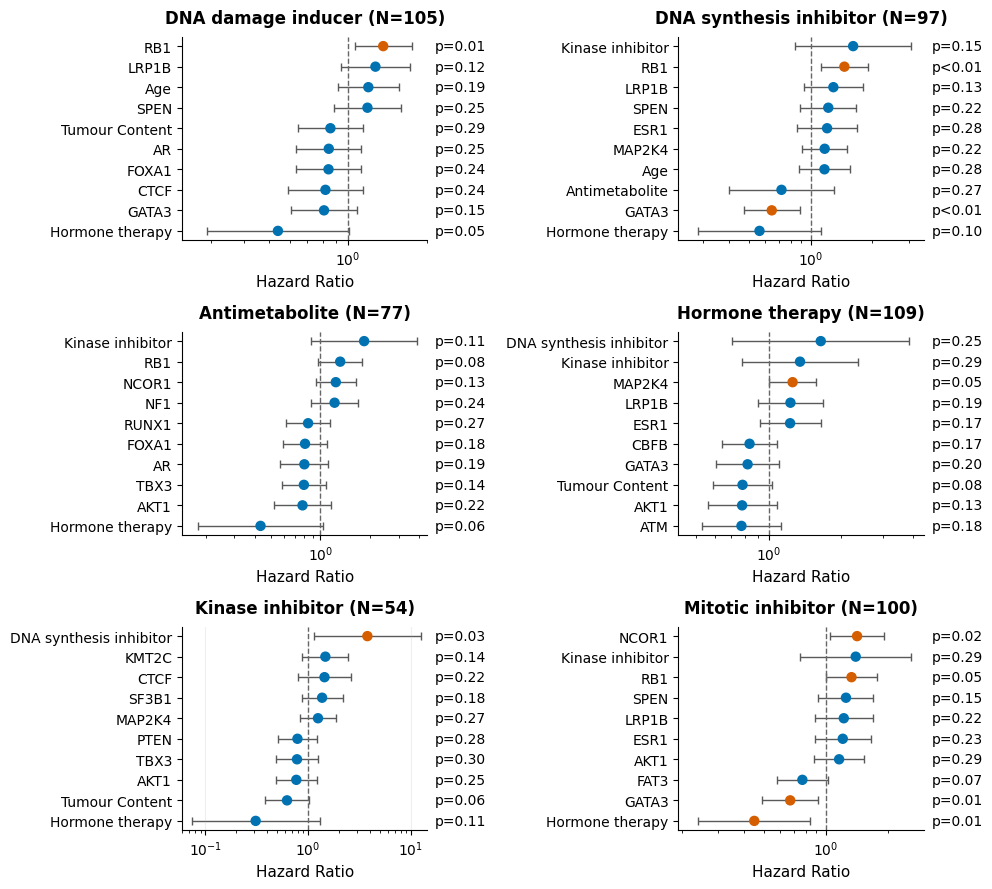

In [17]:
TOP_N_TERMS_FULL_MODEL_PLOT = 10

if treatment_full_model_results.empty:
    print("No full treatment model terms are available for plotting.")
else:
    selected_terms = []
    for treatment_class in sorted(treatment_full_model_results["treatment_class"].unique()):
        class_terms = treatment_full_model_results[
            treatment_full_model_results["treatment_class"].eq(treatment_class)
        ].copy()
        selected_terms.append(class_terms.sort_values("p").head(TOP_N_TERMS_FULL_MODEL_PLOT))

    full_plot_df = pd.concat(selected_terms, ignore_index=True)
    treatment_order = sorted(full_plot_df["treatment_class"].unique())
    n_plots = len(treatment_order)
    n_cols = min(2, n_plots)
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3 * n_rows), squeeze=False)

    for ax, treatment_class in zip(axes.flat, treatment_order):
        class_df = full_plot_df[full_plot_df["treatment_class"].eq(treatment_class)].copy()
        class_df = class_df.sort_values("hazard_ratio").reset_index(drop=True)
        y = np.arange(len(class_df))
        hr = class_df["hazard_ratio"].to_numpy(dtype=float)
        hr_low = class_df["ci_low"].to_numpy(dtype=float)
        hr_high = class_df["ci_high"].to_numpy(dtype=float)
        xerr = np.vstack([hr - hr_low, hr_high - hr])
        colors = np.where(class_df["p"].lt(0.05), "#D55E00", "#0072B2")

        ax.errorbar(hr, y, xerr=xerr, fmt="none", ecolor="0.35", elinewidth=1, capsize=3, zorder=1)
        ax.scatter(hr, y, c=colors, s=42, zorder=2)
        ax.axvline(1, color="0.4", linestyle="--", linewidth=1)
        ax.set_xscale("log")
        ax.set_xlabel("Hazard Ratio", fontsize=11)
        format_log_power_xaxis(ax)
        ax.set_yticks(y)
        ax.set_yticklabels(class_df["term_label"])
        n_patients = int(class_df["n_patients"].iloc[0])
        title_text = treatment_class[:1].upper() + treatment_class[1:]
        ax.set_title(f"{title_text} (N={n_patients})", pad=10, loc="center", x=0.5, fontsize=12, fontweight="bold")

        ax.set_xlim(max(hr_low.min() * 0.8, 1e-3), hr_high.max() * 1.15)
        for y_pos, p_label in zip(y, class_df["p_label"]):
            ax.text(1.03, y_pos, p_label, transform=ax.get_yaxis_transform(), va="center", fontsize=10, clip_on=False)
        ax.grid(axis="x", alpha=0.2)
        sns.despine(ax=ax)

    for ax in axes.flat[n_plots:]:
        ax.axis("off")
    plt.tight_layout(rect=[0, 0, 0.84, 1])
    plt.savefig(f"{OUTPUT_DIR}/{', '.join(CANCER_TYPES)}_full_model_top_{TOP_N_GENES_BY_DISRUPTION}_genes_{DRIVER_GENE_MODE}_genes.png", dpi=300, bbox_inches="tight")
    print(f"Saved plot to {OUTPUT_DIR}/{', '.join(CANCER_TYPES)}_full_model_top_{TOP_N_GENES_BY_DISRUPTION}_genes_{DRIVER_GENE_MODE}_genes.png")